# Versão 4 - Treino, Validação e Comparação entre Modelos

A principal novidade desta etapa é que a versão 4 passa a comparar **duas arquiteturas** sob o mesmo pré-processamento:

- `pure_lstm_forecaster_v4`: uma LSTM mais próxima do que um aluno iniciante espera ver em um projeto de séries temporais;
- `hybrid_residual_forecaster_v4`: uma continuação da ideia híbrida da versão 3, agora adaptada para previsão multi-step.

Além disso, o treino passa a incluir:

- horizonte de previsão maior que 1;
- loss robusta baseada em `smooth_l1`;
- pesos por variável-alvo;
- amostragem mais balanceada por classe no conjunto de treino;
- mixed precision opcional para reduzir custo computacional na GPU.


## 1. Preparação do ambiente

Vamos carregar o bundle gerado no pré-processamento, as funções para montar janelas temporais e as rotinas de treino da versão 4.


In [1]:
from __future__ import annotations

#resolve os caminhos para importar o pipeline_v4 de forma robusta
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd().resolve()
CANDIDATE_DIRS = [
    CURRENT_DIR,
    CURRENT_DIR / "versao4",
    CURRENT_DIR.parent / "versao4",
]
NOTEBOOK_DIR = next((candidate for candidate in CANDIDATE_DIRS if (candidate / "pipeline_v4.py").exists()), CURRENT_DIR)
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "versao4" else NOTEBOOK_DIR
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

#carrega bibliotecas gerais e utilitarios para salvar configuracoes
from copy import deepcopy
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from IPython.display import display

#importa as funcoes centrais de treino e leitura dos dados processados
from pipeline_v4 import (
    GroupedWindowDataset,
    build_model,
    compute_per_feature_metrics,
    load_bundle,
    load_grouped_sequences_from_directory,
    run_epoch,
    set_seed,
)

#fixa a semente para reproduzir amostragens e inicializacao do modelo
set_seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


## 2. Carregamento do bundle e definição do dispositivo

O bundle traz o número de features de entrada, a quantidade de targets, os identificadores de poço e a recomendação de horizonte multi-step. A GPU é usada quando disponível para acelerar o treino.


In [2]:
#define caminhos dos artefatos gerados no pre processamento e dos modelos que serao salvos
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
PREPROCESSED_V4_DIR = ARTIFACTS_DIR / "preprocessed_v4"
BUNDLE_PATH = PREPROCESSED_V4_DIR / "preprocessing_bundle_v4.json"
MODELS_DIR = ARTIFACTS_DIR / "models"
REPORTS_V4_DIR = ARTIFACTS_DIR / "reports_v4"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_V4_DIR.mkdir(parents=True, exist_ok=True)

#carrega o bundle e escolhe gpu quando disponivel
bundle = load_bundle(BUNDLE_PATH)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bundle_runtime_df = pd.DataFrame(
    {
        "aspecto": [
            "device",
            "input_features",
            "target_features",
            "well_count",
            "sequence_length",
            "forecast_horizon",
        ],
        "valor": [
            str(device),
            len(bundle.input_columns),
            len(bundle.target_columns),
            len(bundle.well_to_id),
            bundle.sequence_length_recommendation,
            bundle.forecast_horizon_recommendation,
        ],
    }
)
display(bundle_runtime_df)


,aspecto,valor
0,device,cuda
1,input_features,36
2,target_features,6
3,well_count,42
4,sequence_length,60
5,forecast_horizon,5


## 3. Carregamento das séries processadas e criação das janelas temporais

Agora os arquivos processados viram grupos de séries temporais. Depois, cada grupo é quebrado em várias janelas de entrada e targets futuros. Como a base é enorme, continuamos amostrando janelas por época, mas agora podemos balancear o treino por classe.


In [3]:
#carrega os arquivos processados de treino e validacao como grupos de series temporais
train_groups = load_grouped_sequences_from_directory(
    PREPROCESSED_V4_DIR / "train",
    input_columns=bundle.input_columns,
    target_columns=bundle.target_columns,
)
validation_groups = load_grouped_sequences_from_directory(
    PREPROCESSED_V4_DIR / "validation",
    input_columns=bundle.input_columns,
    target_columns=bundle.target_columns,
)

#define os principais parametros de treino da versao4
SEQUENCE_LENGTH = bundle.sequence_length_recommendation
FORECAST_HORIZON = bundle.forecast_horizon_recommendation
TRAIN_BATCH_SIZE = 128
VALIDATION_BATCH_SIZE = 192
TRAIN_SAMPLED_WINDOWS = 140_000
VALIDATION_SAMPLED_WINDOWS = 50_000
NUM_WORKERS = 4
PIN_MEMORY = device.type == "cuda"
USE_AMP = device.type == "cuda"
BALANCE_TRAIN_BY_CLASS = True

#monta datasets que sabem transformar cada serie em varias janelas temporais multi step
train_dataset = GroupedWindowDataset(
    groups=train_groups,
    sequence_length=SEQUENCE_LENGTH,
    forecast_horizon=FORECAST_HORIZON,
    sampled_windows=TRAIN_SAMPLED_WINDOWS,
    seed=42,
    balance_by_class=BALANCE_TRAIN_BY_CLASS,
)
validation_dataset = GroupedWindowDataset(
    groups=validation_groups,
    sequence_length=SEQUENCE_LENGTH,
    forecast_horizon=FORECAST_HORIZON,
    sampled_windows=VALIDATION_SAMPLED_WINDOWS,
    seed=123,
    balance_by_class=False,
)

#cria dataloaders para entregar batches durante treino e validacao
train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=VALIDATION_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

window_overview_df = pd.DataFrame(
    [
        {
            "split": "train",
            "series": len(train_groups),
            "janelas_ativas": len(train_dataset),
            "janelas_totais": len(train_dataset._full_index),
            "balance_by_class": BALANCE_TRAIN_BY_CLASS,
        },
        {
            "split": "validation",
            "series": len(validation_groups),
            "janelas_ativas": len(validation_dataset),
            "janelas_totais": len(validation_dataset._full_index),
            "balance_by_class": False,
        },
    ]
)
display(window_overview_df)


,split,series,janelas_ativas,janelas_totais,balance_by_class
0,train,1554,140000,54421407,True
1,validation,314,50000,9641372,False


### Leitura da escala do treino nesta execução

O treino potencial tem mais de `54,4 milhões` de janelas e a validação mais de `9,64 milhões`, mas cada época usa apenas uma amostra ativa de `140 mil` e `50 mil` janelas, respectivamente. Essa diferença é o que torna a execução viável na prática.

O lado pedagógico dessa escolha é importante: o modelo não está sendo selecionado com base na validação completa, e sim com base em uma amostra grande, porém parcial. Isso ajuda a explicar por que a história contada pela validação pode não coincidir exatamente com a do teste completo.


### Por que ainda amostrar janelas na versão 4

Mesmo com GPU, treinar em todas as janelas possíveis por época seria caro demais. A estratégia continua sendo usar uma amostra grande, porém viável, e reamostrar essa coleção a cada época. A diferença é que agora o treino pode buscar mais equilíbrio entre classes, o que ajuda a não concentrar tanto aprendizado nas classes mais comuns.


In [4]:
#inspeciona um batch para entender o formato que o modelo vai receber
batch_example = next(iter(train_loader))
{
    "x_shape": tuple(batch_example["x"].shape),
    "y_shape": tuple(batch_example["y"].shape),
    "well_id_shape": tuple(batch_example["well_id"].shape),
    "step_idx_shape": tuple(batch_example["step_idx"].shape),
    "timestamp_ns_shape": tuple(batch_example["timestamp_ns"].shape),
}


{'x_shape': (128, 60, 36),
 'y_shape': (128, 5, 6),
 'well_id_shape': (128,),
 'step_idx_shape': (128, 5),
 'timestamp_ns_shape': (128, 5)}

O lote acima mostra duas dimensões temporais importantes:

- `x_shape`: histórico que entra no modelo;
- `y_shape`: horizonte futuro que o modelo precisa prever.

Na versão 3, `y` tinha apenas um passo. Agora, `y` passa a ter vários passos futuros, o que torna o problema mais realista e também mais difícil.


## 4. Configuração dos modelos e da loss

Aqui definimos duas arquiteturas e também os pesos da loss por target. Esses pesos são uma forma simples de dar mais atenção a variáveis que já se mostraram difíceis na versão 3, como `P-ANULAR`, `P-JUS-CKGL` e `P-TPT`.


In [5]:
#descobre em quais posicoes da entrada ficam as variaveis alvo em sua forma crua normalizada
RAW_TARGET_POSITIONS = [bundle.input_columns.index(column_name) for column_name in bundle.raw_target_input_columns]

#define pesos maiores para targets que ainda sofreram mais na versao3
TARGET_WEIGHT_MAP = {
    "P-ANULAR": 1.35,
    "P-JUS-CKGL": 1.25,
    "P-MON-CKP": 1.00,
    "P-TPT": 1.35,
    "T-JUS-CKP": 1.00,
    "T-TPT": 1.00,
}
TARGET_WEIGHTS = [TARGET_WEIGHT_MAP[column] for column in bundle.target_columns]

#atribui pesos ligeiramente decrescentes para horizontes mais distantes sem zerar sua importancia
HORIZON_WEIGHTS = np.linspace(1.0, 0.8, FORECAST_HORIZON).round(3).tolist()

#define duas arquiteturas para comparacao justa sob o mesmo pre processamento
MODEL_SPECS = [
    {
        "model_name": "pure_lstm_forecaster_v4",
        "display_name": "LSTM pura",
        "model_dim": 128,
        "hidden_size": 128,
        "recurrent_layers": 2,
        "well_embedding_dim": 16,
        "dropout": 0.20,
    },
    {
        "model_name": "hybrid_residual_forecaster_v4",
        "display_name": "Hibrido residual",
        "model_dim": 128,
        "hidden_size": 128,
        "recurrent_layers": 2,
        "well_embedding_dim": 16,
        "dropout": 0.20,
    },
]

pd.DataFrame(
    {
        "target": bundle.target_columns,
        "target_weight": TARGET_WEIGHTS,
    }
)


,target,target_weight
0,P-ANULAR,1.35
1,P-JUS-CKGL,1.25
2,P-MON-CKP,1.00
3,P-TPT,1.35
4,T-JUS-CKP,1.00
5,T-TPT,1.00


## 5. Treino e validação por época

Vamos treinar cada arquitetura separadamente, salvar o melhor checkpoint e registrar histórico, métricas agregadas e métricas por variável no melhor ponto de validação.


In [6]:
#define hiperparametros principais de otimizacao e parada
MAX_EPOCHS = 20
PATIENCE = 5
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

#cria estruturas para guardar comparacoes entre modelos
#nesta versao a validacao e amostrada, entao o teste completo ainda pode contar uma historia um pouco diferente
comparison_rows = []
history_frames = []
best_feature_tables = {}

def train_single_model(model_spec: dict[str, object]) -> tuple[dict[str, object], pd.DataFrame, pd.DataFrame]:
    #instancia a arquitetura atual
    model = build_model(
        model_name=str(model_spec["model_name"]),
        input_size=len(bundle.input_columns),
        target_size=len(bundle.target_columns),
        forecast_horizon=FORECAST_HORIZON,
        well_count=max(len(bundle.well_to_id), 1),
        raw_target_positions=RAW_TARGET_POSITIONS,
        model_dim=int(model_spec["model_dim"]),
        hidden_size=int(model_spec["hidden_size"]),
        recurrent_layers=int(model_spec["recurrent_layers"]),
        well_embedding_dim=int(model_spec["well_embedding_dim"]),
        dropout=float(model_spec["dropout"]),
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer=optimizer,
        mode="min",
        factor=0.5,
        patience=2,
    )
    grad_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    history_rows = []
    best_state_dict = None
    best_epoch = None
    best_score = np.inf
    best_val_metrics = None
    best_per_feature_df = pd.DataFrame()
    patience_counter = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        #reamostra janelas a cada epoca para explorar melhor o volume total de dados disponiveis
        train_dataset.resample(epoch)
        validation_dataset.resample(epoch)

        #executa uma epoca de treino e outra de validacao
        train_metrics = run_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            device=device,
            raw_target_positions=RAW_TARGET_POSITIONS,
            target_weights=TARGET_WEIGHTS,
            horizon_weights=HORIZON_WEIGHTS,
            use_amp=USE_AMP,
            grad_scaler=grad_scaler,
        )
        validation_metrics = run_epoch(
            model=model,
            loader=validation_loader,
            optimizer=None,
            device=device,
            raw_target_positions=RAW_TARGET_POSITIONS,
            target_weights=TARGET_WEIGHTS,
            horizon_weights=HORIZON_WEIGHTS,
            use_amp=USE_AMP,
            grad_scaler=None,
        )

        #ajusta a taxa de aprendizado quando a validacao deixa de melhorar
        scheduler.step(validation_metrics["model_mae"])

        #usa a razao entre o mae do modelo e o mae da persistencia como score principal
        current_score = validation_metrics["model_mae"] / max(validation_metrics["persistence_mae"], 1e-8)
        per_feature_df = compute_per_feature_metrics(
            validation_metrics["y_true"],
            validation_metrics["y_pred"],
            validation_metrics["y_persist"],
            bundle.target_columns,
        )
        persistence_wins = int((per_feature_df["mae_melhora_pct"] < 0).sum())

        history_rows.append(
            {
                "model_name": model_spec["model_name"],
                "display_name": model_spec["display_name"],
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_mae": train_metrics["model_mae"],
                "val_loss": validation_metrics["loss"],
                "val_mae": validation_metrics["model_mae"],
                "val_persistence_mae": validation_metrics["persistence_mae"],
                "val_mae_ratio_to_persistence": current_score,
                "val_improvement_pct": validation_metrics["mae_improvement_pct"],
                "features_where_persistence_wins": persistence_wins,
                "learning_rate": optimizer.param_groups[0]["lr"],
            }
        )

        print(
            f"[{model_spec['model_name']}] Epoch {epoch:02d} | "
            f"train_loss={train_metrics['loss']:.5f} | "
            f"val_loss={validation_metrics['loss']:.5f} | "
            f"val_mae={validation_metrics['model_mae']:.5f} | "
            f"persist_mae={validation_metrics['persistence_mae']:.5f} | "
            f"ratio={current_score:.4f} | "
            f"improvement={validation_metrics['mae_improvement_pct']:.2f}% | "
            f"persist_wins={persistence_wins}"
        )

        #salva o melhor estado encontrado ate agora
        if current_score < best_score:
            best_score = current_score
            best_epoch = epoch
            best_state_dict = deepcopy(model.state_dict())
            best_val_metrics = validation_metrics
            best_per_feature_df = per_feature_df.copy()
            patience_counter = 0
        else:
            patience_counter += 1

        #interrompe o treino quando a validacao para de melhorar por varias epocas seguidas
        if patience_counter >= PATIENCE:
            print(f"Parada antecipada em {model_spec['model_name']} no epoch {epoch}.")
            break

    #restaura o melhor checkpoint antes de salvar
    model.load_state_dict(best_state_dict)

    model_path = MODELS_DIR / f"{model_spec['model_name']}.pt"
    history_path = REPORTS_V4_DIR / f"{model_spec['model_name']}_history.csv"
    feature_path = REPORTS_V4_DIR / f"{model_spec['model_name']}_best_per_feature.csv"
    config_path = MODELS_DIR / f"{model_spec['model_name']}_config.json"

    torch.save(model.state_dict(), model_path)
    history_df = pd.DataFrame(history_rows)
    history_df.to_csv(history_path, index=False)
    best_per_feature_df.to_csv(feature_path, index=False)

    model_config = {
        "model_name": model_spec["model_name"],
        "display_name": model_spec["display_name"],
        "input_size": len(bundle.input_columns),
        "target_size": len(bundle.target_columns),
        "forecast_horizon": FORECAST_HORIZON,
        "sequence_length": SEQUENCE_LENGTH,
        "raw_target_positions": RAW_TARGET_POSITIONS,
        "model_dim": int(model_spec["model_dim"]),
        "hidden_size": int(model_spec["hidden_size"]),
        "recurrent_layers": int(model_spec["recurrent_layers"]),
        "well_embedding_dim": int(model_spec["well_embedding_dim"]),
        "dropout": float(model_spec["dropout"]),
        "train_batch_size": TRAIN_BATCH_SIZE,
        "validation_batch_size": VALIDATION_BATCH_SIZE,
        "train_sampled_windows": TRAIN_SAMPLED_WINDOWS,
        "validation_sampled_windows": VALIDATION_SAMPLED_WINDOWS,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
        "use_amp": USE_AMP,
        "balance_train_by_class": BALANCE_TRAIN_BY_CLASS,
        "target_weights": TARGET_WEIGHTS,
        "horizon_weights": HORIZON_WEIGHTS,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "best_epoch": int(best_epoch),
        "best_val_mae": float(best_val_metrics["model_mae"]),
        "best_val_persistence_mae": float(best_val_metrics["persistence_mae"]),
        "best_ratio_to_persistence": float(best_score),
        "best_improvement_pct": float(best_val_metrics["mae_improvement_pct"]),
        "executed_epochs": int(len(history_df)),
        "bundle_path": str(BUNDLE_PATH),
        "model_path": str(model_path),
        "history_path": str(history_path),
        "best_per_feature_path": str(feature_path),
        "config_path": str(config_path),
    }
    config_path.write_text(json.dumps(model_config, ensure_ascii=False, indent=2))

    summary_row = {
        "model_name": model_spec["model_name"],
        "display_name": model_spec["display_name"],
        "best_epoch": int(best_epoch),
        "best_val_mae": float(best_val_metrics["model_mae"]),
        "best_val_persistence_mae": float(best_val_metrics["persistence_mae"]),
        "best_ratio_to_persistence": float(best_score),
        "best_improvement_pct": float(best_val_metrics["mae_improvement_pct"]),
        "executed_epochs": int(len(history_df)),
        "features_where_persistence_wins": int((best_per_feature_df["mae_melhora_pct"] < 0).sum()),
        "model_path": str(model_path),
        "config_path": str(config_path),
        "history_path": str(history_path),
        "best_per_feature_path": str(feature_path),
    }
    return summary_row, history_df, best_per_feature_df

for model_spec in MODEL_SPECS:
    summary_row, history_df, best_per_feature_df = train_single_model(model_spec)
    comparison_rows.append(summary_row)
    history_frames.append(history_df)
    best_feature_tables[summary_row["model_name"]] = best_per_feature_df

comparison_df = pd.DataFrame(comparison_rows).sort_values(["best_ratio_to_persistence", "best_val_mae"])
combined_history_df = pd.concat(history_frames, ignore_index=True)
comparison_df.to_csv(REPORTS_V4_DIR / "model_comparison_v4.csv", index=False)
combined_history_df.to_csv(REPORTS_V4_DIR / "combined_history_v4.csv", index=False)

display(comparison_df)


/tmp/ipykernel_214858/1409936951.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  grad_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


[pure_lstm_forecaster_v4] Epoch 01 | train_loss=0.00018 | val_loss=0.00000 | val_mae=0.00118 | persist_mae=0.00021 | ratio=5.6604 | improvement=-466.04% | persist_wins=6
[pure_lstm_forecaster_v4] Epoch 02 | train_loss=0.00001 | val_loss=0.00000 | val_mae=0.00064 | persist_mae=0.00021 | ratio=3.0733 | improvement=-207.33% | persist_wins=6
[pure_lstm_forecaster_v4] Epoch 03 | train_loss=0.00001 | val_loss=0.00000 | val_mae=0.00047 | persist_mae=0.00021 | ratio=2.2502 | improvement=-125.02% | persist_wins=6
[pure_lstm_forecaster_v4] Epoch 04 | train_loss=0.00000 | val_loss=0.00000 | val_mae=0.00040 | persist_mae=0.00021 | ratio=1.9361 | improvement=-93.61% | persist_wins=6
[pure_lstm_forecaster_v4] Epoch 05 | train_loss=0.00000 | val_loss=0.00000 | val_mae=0.00036 | persist_mae=0.00021 | ratio=1.7526 | improvement=-75.26% | persist_wins=6
[pure_lstm_forecaster_v4] Epoch 06 | train_loss=0.00000 | val_loss=0.00000 | val_mae=0.00039 | persist_mae=0.00021 | ratio=1.8554 | improvement=-85.54% 

/tmp/ipykernel_214858/1409936951.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  grad_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


[hybrid_residual_forecaster_v4] Epoch 01 | train_loss=0.00004 | val_loss=0.00000 | val_mae=0.00052 | persist_mae=0.00021 | ratio=2.4780 | improvement=-147.80% | persist_wins=6
[hybrid_residual_forecaster_v4] Epoch 02 | train_loss=0.00000 | val_loss=0.00000 | val_mae=0.00039 | persist_mae=0.00021 | ratio=1.8591 | improvement=-85.91% | persist_wins=6
[hybrid_residual_forecaster_v4] Epoch 03 | train_loss=0.00000 | val_loss=0.00000 | val_mae=0.00030 | persist_mae=0.00021 | ratio=1.4318 | improvement=-43.18% | persist_wins=6
[hybrid_residual_forecaster_v4] Epoch 04 | train_loss=0.00000 | val_loss=0.00000 | val_mae=0.00032 | persist_mae=0.00021 | ratio=1.5506 | improvement=-55.06% | persist_wins=6
[hybrid_residual_forecaster_v4] Epoch 05 | train_loss=0.00000 | val_loss=0.00000 | val_mae=0.00032 | persist_mae=0.00021 | ratio=1.5172 | improvement=-51.72% | persist_wins=6
[hybrid_residual_forecaster_v4] Epoch 06 | train_loss=0.00000 | val_loss=0.00000 | val_mae=0.00033 | persist_mae=0.00021 | r

,model_name,display_name,best_epoch,best_val_mae,best_val_persistence_mae,best_ratio_to_persistence,best_improvement_pct,executed_epochs,features_where_persistence_wins,model_path,config_path,history_path,best_per_feature_path
0,pure_lstm_forecaster_v4,LSTM pura,18,0.000239,0.000208,1.149055,-14.905538,20,5,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...
1,hybrid_residual_forecaster_v4,Hibrido residual,3,0.000298,0.000208,1.431792,-43.179200,8,6,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...


### Leitura desta execução de treino e validação

A `LSTM pura` venceu a comparação entre arquiteturas, mas a vitória foi relativa: ela foi apenas menos fraca do que o modelo híbrido na validação amostrada. O melhor checkpoint da LSTM ficou no `epoch 18`, com razão `1,149` em relação à persistência, enquanto o híbrido parou cedo no `epoch 8`, com razão `1,432`.

O resultado mais importante aqui é que **nenhum dos dois modelos superou a persistência na validação**. Isso significa que, ao final deste notebook, a postura correta ainda é de cautela. O experimento encontrou um campeão interno, mas ainda não uma vitória convincente contra a baseline.

Também vale notar que a LSTM melhorou depois da redução da taxa de aprendizado para `0,00015`, perto do epoch 15. Isso sugere que a arquitetura precisava de atualizações mais suaves para estabilizar o erro.


### Como interpretar a tabela de comparação

O indicador principal continua sendo a razão entre o MAE do modelo e o MAE da persistência. Quanto menor essa razão, melhor. Um valor abaixo de `1.0` significa que o modelo conseguiu superar a baseline.

A coluna `features_where_persistence_wins` é um complemento importante: ela mostra em quantas variáveis a persistência ainda ficou melhor no melhor checkpoint. Isso é útil porque um modelo pode ir bem no agregado e, mesmo assim, continuar fraco em targets específicos.


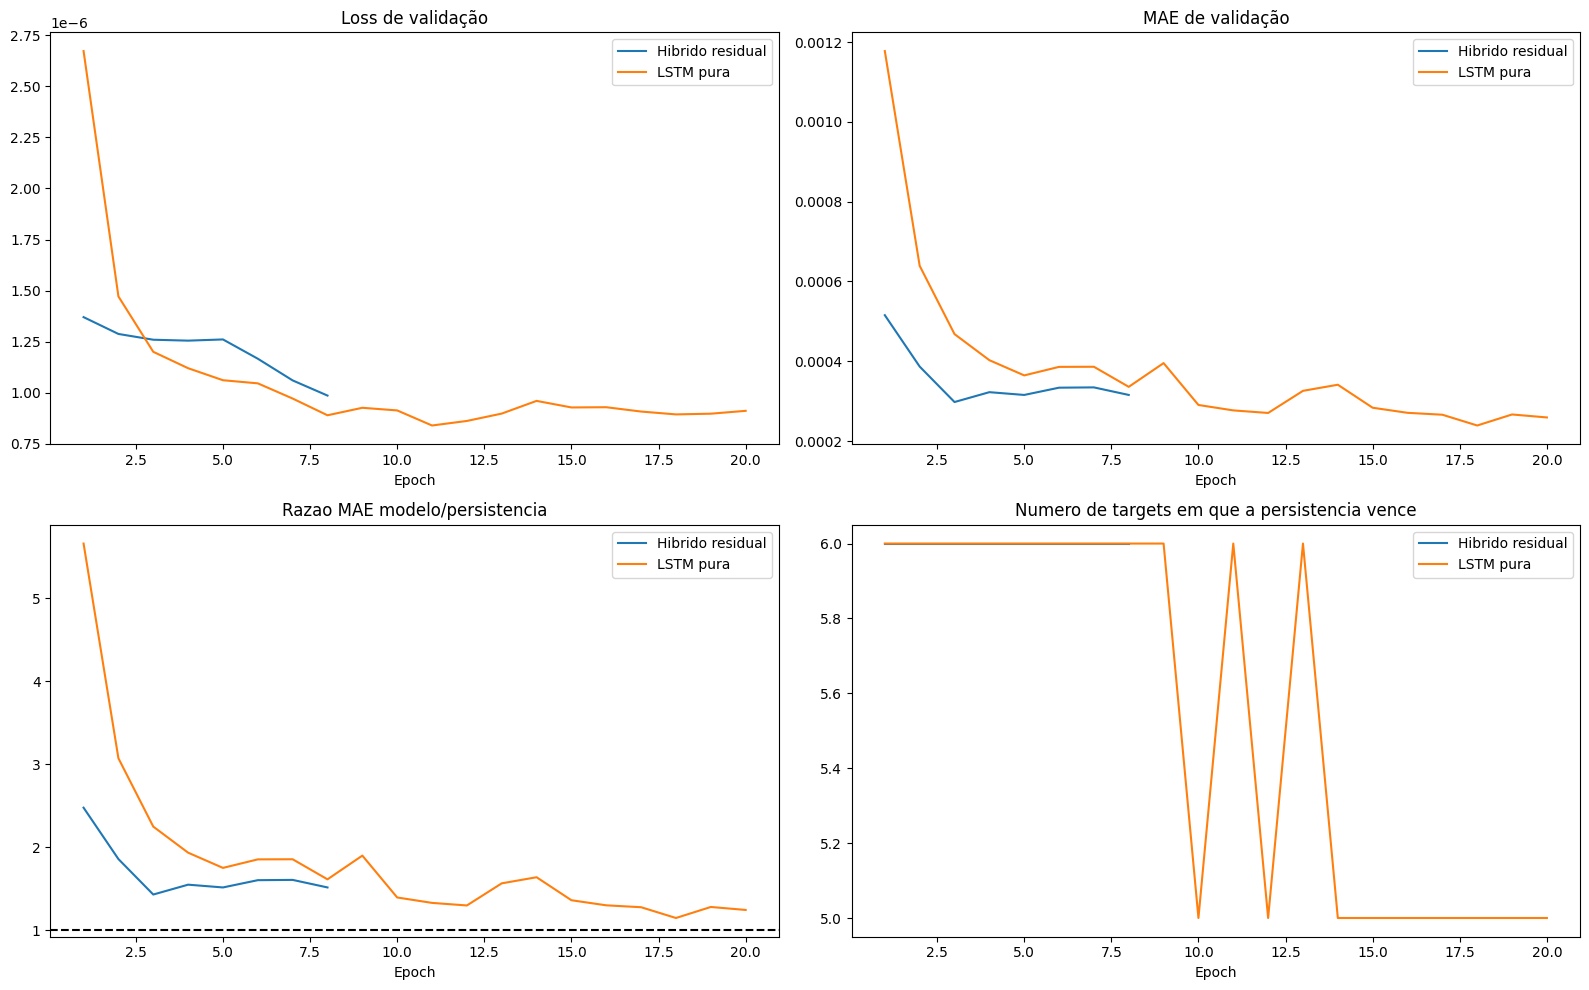

In [7]:
#plota a evolucao das metricas principais para comparar as arquiteturas ao longo das epocas
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for model_name, history_df in combined_history_df.groupby("model_name"):
    display_name = history_df["display_name"].iloc[0]
    axes[0, 0].plot(history_df["epoch"], history_df["val_loss"], label=display_name)
    axes[0, 1].plot(history_df["epoch"], history_df["val_mae"], label=display_name)
    axes[1, 0].plot(history_df["epoch"], history_df["val_mae_ratio_to_persistence"], label=display_name)
    axes[1, 1].plot(history_df["epoch"], history_df["features_where_persistence_wins"], label=display_name)

axes[0, 0].set_title("Loss de validação")
axes[0, 1].set_title("MAE de validação")
axes[1, 0].set_title("Razao MAE modelo/persistencia")
axes[1, 0].axhline(1.0, color="black", linestyle="--")
axes[1, 1].set_title("Numero de targets em que a persistencia vence")

for axis in axes.ravel():
    axis.legend()
    axis.set_xlabel("Epoch")

plt.tight_layout()
plt.show()


## 6. Inspeção do melhor modelo

Depois da comparação global, vale olhar a tabela de métricas por variável do modelo vencedor. Isso ajuda a responder se o ganho aconteceu de forma consistente ou se ele ficou concentrado em poucas variáveis.


In [8]:
#seleciona o modelo vencedor segundo o score principal da validacao
champion_row = comparison_df.iloc[0].to_dict()
champion_model_name = champion_row["model_name"]
champion_features_df = best_feature_tables[champion_model_name].copy()

display(pd.DataFrame([champion_row]))
display(champion_features_df)


,model_name,display_name,best_epoch,best_val_mae,best_val_persistence_mae,best_ratio_to_persistence,best_improvement_pct,executed_epochs,features_where_persistence_wins,model_path,config_path,history_path,best_per_feature_path
0,pure_lstm_forecaster_v4,LSTM pura,18,0.000239,0.000208,1.149055,-14.905538,20,5,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...


,feature,model_mae,baseline_mae,mae_melhora_pct,model_mse,baseline_mse,model_rmse,baseline_rmse,rmse_melhora_pct,model_r2,baseline_r2,model_bias,model_residual_std
0,P-MON-CKP,0.000729,0.000660,-10.357144,9.130374e-06,1.326366e-05,0.003022,0.003642,17.031634,0.999979,0.999970,-0.000234,0.003013
1,T-JUS-CKP,0.000228,0.000157,-45.714414,1.653912e-06,2.002900e-06,0.001286,0.001415,9.128731,0.999991,0.999990,0.000018,0.001286
2,T-TPT,0.000166,0.000124,-34.318952,6.568992e-07,7.212320e-07,0.000810,0.000849,4.564079,0.999999,0.999999,0.000029,0.000810
3,P-JUS-CKGL,0.000101,0.000083,-22.585509,6.259159e-07,6.860231e-07,0.000791,0.000828,4.481250,1.000000,1.000000,-0.000015,0.000791
4,P-TPT,0.000151,0.000197,22.933915,2.961941e-07,6.375545e-07,0.000544,0.000798,31.840009,1.000000,0.999999,0.000010,0.000544
5,P-ANULAR,0.000058,0.000028,-106.065130,3.802444e-08,3.642476e-08,0.000195,0.000191,-2.172279,1.000000,1.000000,0.000017,0.000194


### Leitura do modelo campeão na validação

No melhor checkpoint da validação, apenas `P-TPT` superou a persistência em MAE. Já `P-MON-CKP` perdeu em MAE, mas ganhou em RMSE. Esse contraste é ótimo para ensino: MAE e RMSE não medem exatamente a mesma coisa.

O MAE olha o erro médio absoluto e trata todos os desvios de forma linear. O RMSE penaliza muito mais os erros grandes. Então um modelo pode errar um pouco mais no dia a dia e, ainda assim, evitar melhor os erros extremos. Esse detalhe será importante quando compararmos a validação com o teste completo.


## Conclusão da etapa

A versão 4 deixa o treino mais completo em dois sentidos:

1. ensina melhor, porque mostra uma comparação direta entre uma LSTM clássica e um modelo mais híbrido;
2. experimenta melhor, porque considera horizonte multi-step, loss robusta, pesos por target e amostragem mais balanceada.

O próximo notebook vai avaliar o modelo escolhido no conjunto de teste em modo streaming, com relatórios por variável, classe, poço, série e horizonte.
